In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import Holt, SimpleExpSmoothing
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

## Proyeksi Trend NEET menggunakan Time Series

### Proyeksi NEET dengan ARIMA

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


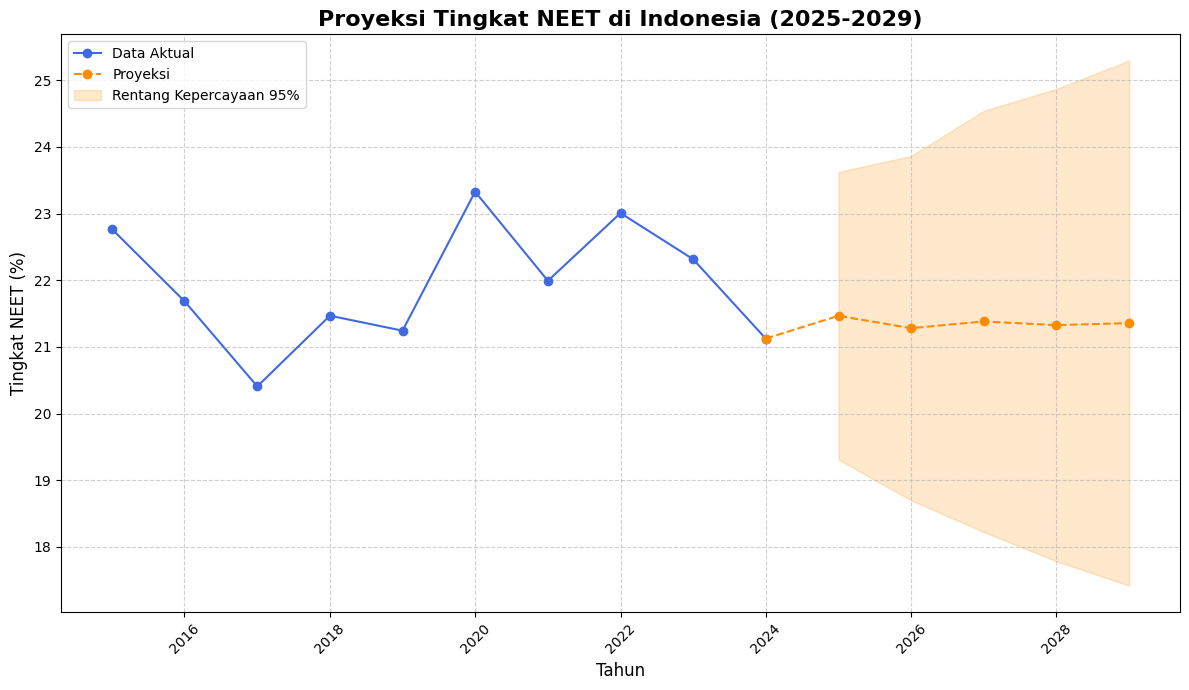

In [41]:
# Membaca data dari file CSV yang diunggah
neet = pd.read_excel("C:/Uner/Lomba/OLS/Dataset/Data NEET.xlsx")

# Menghitung rata-rata tingkat NEET nasional
national_neet = neet.drop('Provinsi', axis=1).mean()
national_neet.index = pd.to_datetime(national_neet.index, format='%Y')

# Membangun dan melatih model ARIMA
model = ARIMA(national_neet, order=(1, 1, 1))
model_fit = model.fit()

# Membuat proyeksi untuk 5 tahun ke depan
forecast = model_fit.get_forecast(steps=5)
forecast_index = pd.to_datetime(['2025', '2026', '2027', '2028', '2029'], format='%Y')
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()


# --- Bagian Visualisasi (Dimodifikasi) ---

# Ambil titik data historis terakhir untuk menyambungkan plot
last_historical_year = national_neet.index[-1]
last_historical_value = national_neet.values[-1]

# Buat index dan data baru untuk garis proyeksi yang sudah tersambung
# Dimulai dari tahun terakhir data historis
connected_forecast_index = pd.Index([last_historical_year]).append(forecast_index)
connected_forecast_values = np.insert(forecast_values.values, 0, last_historical_value)

# Membuat visualisasi data historis dan proyeksi
plt.figure(figsize=(12, 7))

# Plot data aktual (historis)
plt.plot(national_neet.index, national_neet.values, 'o-', label='Data Aktual', color='royalblue')

# Plot garis proyeksi yang sudah tersambung dengan data historis
# Menggunakan linestyle putus-putus (--) untuk membedakan proyeksi
plt.plot(connected_forecast_index, connected_forecast_values, 'o--', label='Proyeksi', color='darkorange')

# Area untuk rentang kepercayaan (confidence interval)
plt.fill_between(forecast_index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1], color='darkorange', alpha=0.2, label='Rentang Kepercayaan 95%')

# Menambahkan judul dan label
plt.title('Proyeksi Tingkat NEET di Indonesia (2025-2029)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Tingkat NEET (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout() # Menyesuaikan plot agar pas

# Menampilkan plot
plt.show()

### Proyeksi Menggunakan Holt's Linear Trend

Proyeksi Tingkat NEET (Holt's Linear Trend):
- 2025: 22.14%
- 2026: 22.17%
- 2027: 22.21%
- 2028: 22.24%
- 2029: 22.27%


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


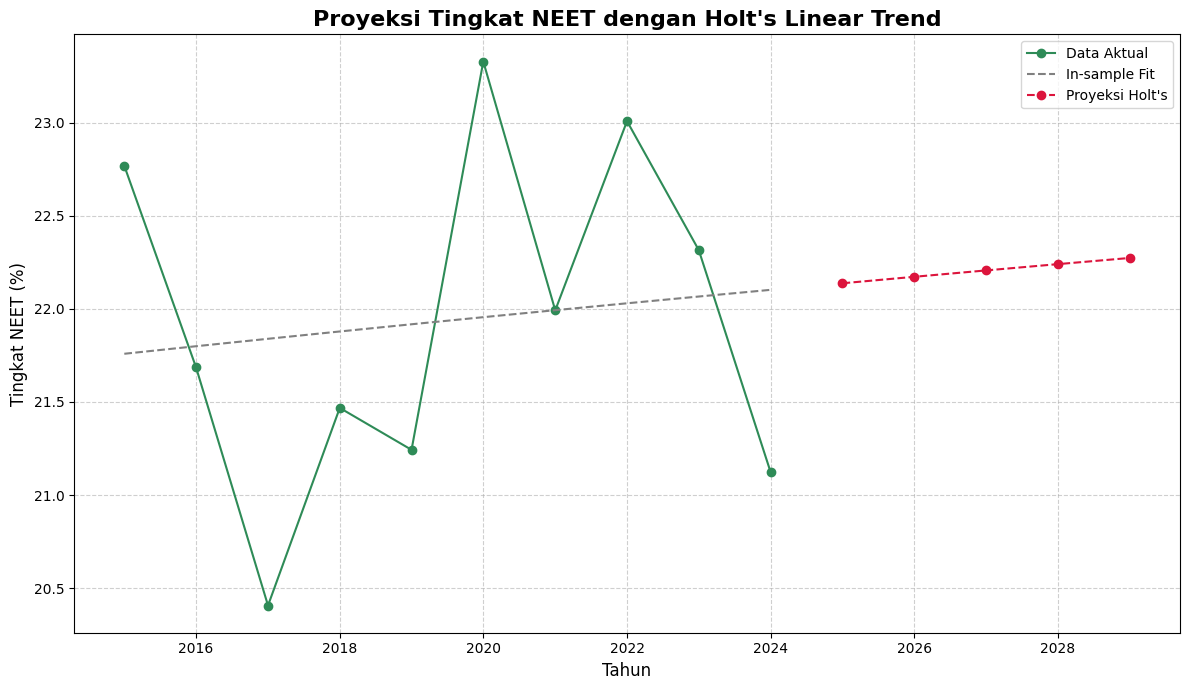

In [42]:
national_neet = neet.drop('Provinsi', axis=1).mean()
national_neet.index = pd.to_datetime(national_neet.index, format='%Y')

# --- Membuat Model Holt's Linear Trend ---
# 'damped_trend=True' seringkali meningkatkan akurasi untuk jangka panjang
model_holt = Holt(national_neet, damped_trend=True, initialization_method="estimated")
fit_holt = model_holt.fit()

# Membuat proyeksi untuk 5 tahun ke depan
forecast_holt = fit_holt.forecast(5)
forecast_index = pd.to_datetime(['2025', '2026', '2027', '2028', '2029'], format='%Y')

# Menampilkan hasil proyeksi Holt's
print("Proyeksi Tingkat NEET (Holt's Linear Trend):")
for year, value in zip(forecast_index.year, forecast_holt):
    print(f"- {year}: {value:.2f}%")

# --- Visualisasi Model Holt's ---
plt.figure(figsize=(12, 7))
plt.plot(national_neet.index, national_neet.values, 'o-', label='Data Aktual', color='seagreen')
plt.plot(national_neet.index, fit_holt.fittedvalues, '--', color='gray', label='In-sample Fit')
plt.plot(forecast_index, forecast_holt, 'o--', label='Proyeksi Holt\'s', color='crimson')

plt.title("Proyeksi Tingkat NEET dengan Holt's Linear Trend", fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Tingkat NEET (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [43]:
# --- Kode untuk Evaluasi ---
# Persiapkan data model ARIMA dari langkah sebelumnya
from statsmodels.tsa.arima.model import ARIMA
model_arima = ARIMA(national_neet, order=(1, 1, 1))
fit_arima = model_arima.fit()

# Hitung error untuk ARIMA
mae_arima = mean_absolute_error(national_neet, fit_arima.fittedvalues)
rmse_arima = np.sqrt(mean_squared_error(national_neet, fit_arima.fittedvalues))

# Hitung error untuk Holt's
mae_holt = mean_absolute_error(national_neet, fit_holt.fittedvalues)
rmse_holt = np.sqrt(mean_squared_error(national_neet, fit_holt.fittedvalues))

# Tampilkan tabel perbandingan
evaluation_df = pd.DataFrame({
    'Metrik': ['MAE', 'RMSE'],
    'ARIMA': [mae_arima, rmse_arima],
    "Holt's Linear Trend": [mae_holt, rmse_holt]
})

print(evaluation_df.round(3))

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


  Metrik  ARIMA  Holt's Linear Trend
0    MAE  3.111                0.722
1   RMSE  7.277                0.870


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


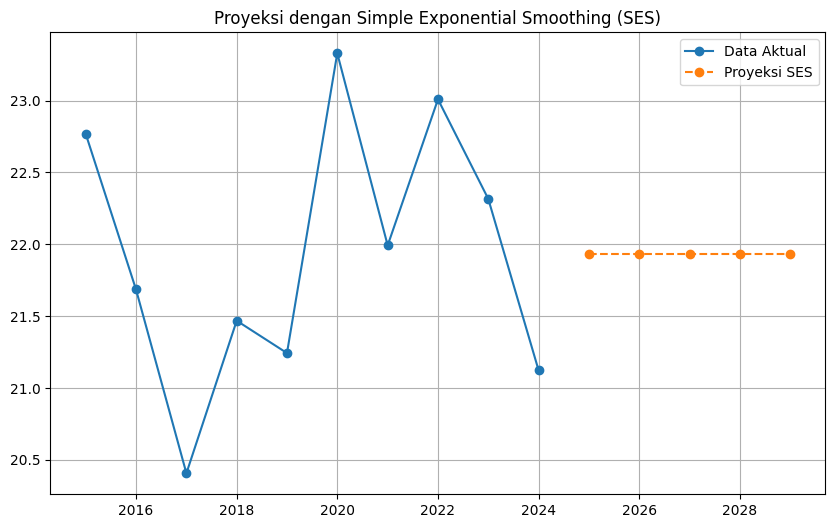

20:25:53 - cmdstanpy - INFO - Chain [1] start processing
20:25:53 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


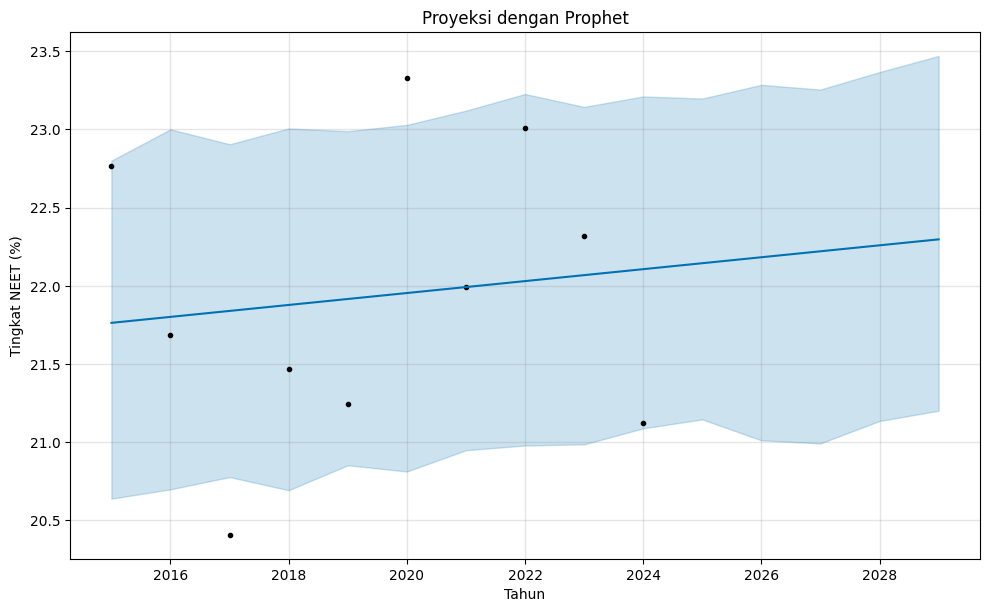

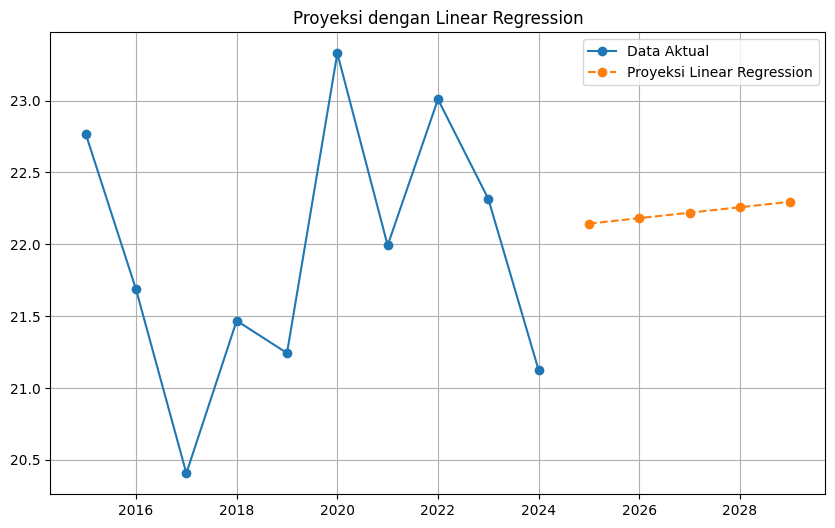

In [44]:
national_neet = neet.drop('Provinsi', axis=1).mean()
national_neet.index = pd.to_datetime(national_neet.index, format='%Y')

# --- MODEL 3: SIMPLE EXPONENTIAL SMOOTHING (SES) ---
model_ses = SimpleExpSmoothing(national_neet, initialization_method="estimated")
fit_ses = model_ses.fit()
forecast_ses = fit_ses.forecast(5)
mae_ses = mean_absolute_error(national_neet, fit_ses.fittedvalues)
rmse_ses = np.sqrt(mean_squared_error(national_neet, fit_ses.fittedvalues))

# Visualisasi SES
plt.figure(figsize=(10, 6))
plt.plot(national_neet.index, national_neet.values, 'o-', label='Data Aktual')
plt.plot(forecast_ses.index, forecast_ses.values, 'o--', label='Proyeksi SES')
plt.title('Proyeksi dengan Simple Exponential Smoothing (SES)')
plt.legend()
plt.grid(True)
plt.show()

# --- MODEL 4: PROPHET ---
# Persiapan data untuk Prophet
df_prophet = national_neet.reset_index()
df_prophet.columns = ['ds', 'y']

# Inisialisasi dan fit model
model_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
model_prophet.fit(df_prophet)

# Buat dataframe masa depan dan prediksi
future = model_prophet.make_future_dataframe(periods=5, freq='A')
forecast_prophet = model_prophet.predict(future)
# Ambil nilai in-sample dan forecast
fitted_prophet = forecast_prophet.iloc[:len(national_neet)]['yhat']
forecast_values_prophet = forecast_prophet.iloc[len(national_neet):]['yhat']
mae_prophet = mean_absolute_error(national_neet.values, fitted_prophet)
rmse_prophet = np.sqrt(mean_squared_error(national_neet.values, fitted_prophet))

# Visualisasi Prophet
fig1 = model_prophet.plot(forecast_prophet)
ax = fig1.gca()
ax.set_title("Proyeksi dengan Prophet")
ax.set_xlabel("Tahun")
ax.set_ylabel("Tingkat NEET (%)")
plt.show()

# --- MODEL 5: LINEAR REGRESSION ---
# Persiapan data untuk regresi
X = np.array([int(i.strftime('%Y')) for i in national_neet.index]).reshape(-1, 1)
y = national_neet.values

# Fit model
model_lr = LinearRegression()
model_lr.fit(X, y)

# Buat prediksi in-sample dan forecast
fitted_lr = model_lr.predict(X)
future_years = np.array([2025, 2026, 2027, 2028, 2029]).reshape(-1, 1)
forecast_lr = model_lr.predict(future_years)
mae_lr = mean_absolute_error(y, fitted_lr)
rmse_lr = np.sqrt(mean_squared_error(y, fitted_lr))

# Visualisasi Linear Regression
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'o-', label='Data Aktual')
plt.plot(future_years, forecast_lr, 'o--', label='Proyeksi Linear Regression')
plt.title('Proyeksi dengan Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

## Analisis Clustering

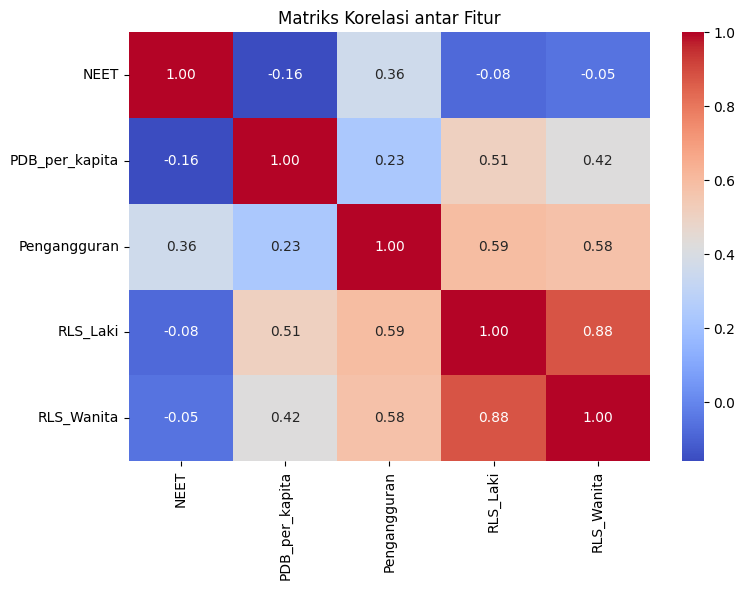

In [45]:
# Load dataset
df = pd.read_excel("C:/Uner/Lomba/OLS/Dataset/Data Clustering.xlsx", sheet_name="Sheet1")

# Rename kolom agar mudah digunakan
df.columns = ['Provinsi', 'NEET', 'PDB_per_kapita', 'Pengangguran', 'RLS_Laki', 'RLS_Wanita']

# Standarisasi fitur numerik
features = ['NEET', 'PDB_per_kapita', 'Pengangguran', 'RLS_Laki', 'RLS_Wanita']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Simpan hasil ke DataFrame
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['Provinsi'] = df['Provinsi']

# Analisis korelasi
correlation_matrix = df[features].corr()

# Visualisasi korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi antar Fitur")
plt.tight_layout()
plt.show()


#### K-Means Clustering

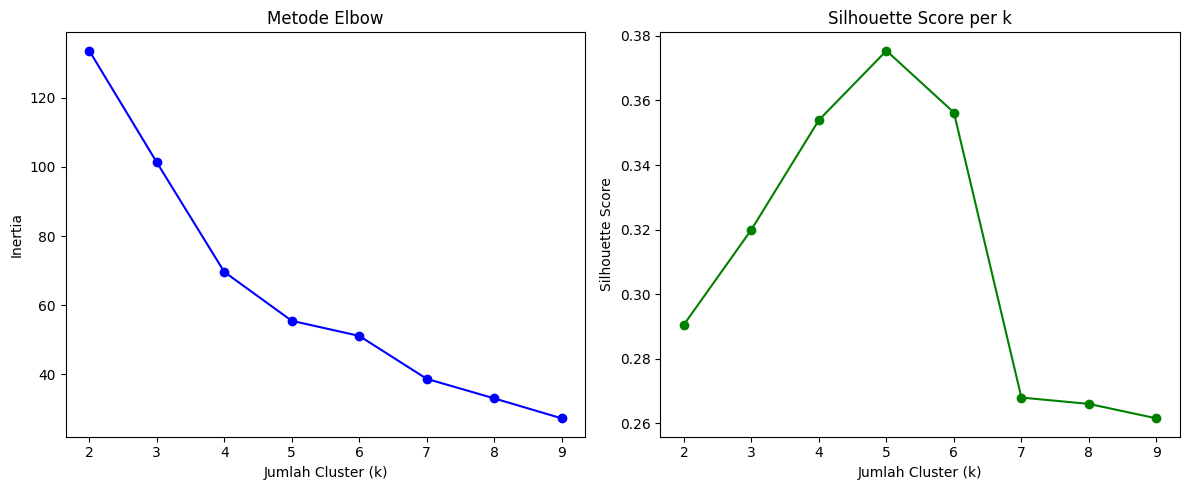

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Cari jumlah cluster optimal dengan Elbow method
inertia = []
silhouette_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow dan Silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow')

plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'go-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per k')
plt.tight_layout()
plt.show()

# Pilih k terbaik, misal k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_scaled['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)


In [47]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Dataset untuk clustering
X = df_scaled[features]

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
df_scaled['KMeans'] = kmeans_labels

# DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=3)
dbscan_labels = dbscan.fit_predict(X)
df_scaled['DBSCAN'] = dbscan_labels

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X)
df_scaled['GMM'] = gmm_labels

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hier_labels = hierarchical.fit_predict(X)
df_scaled['Hierarchical'] = hier_labels


In [48]:
# Evaluasi Silhouette Score untuk metode yang memungkinkan
scores = {
    'KMeans': silhouette_score(X, kmeans_labels),
    'GMM': silhouette_score(X, gmm_labels),
    'Hierarchical': silhouette_score(X, hier_labels),
}

# Silhouette score DBSCAN hanya jika tidak semua -1
if len(set(dbscan_labels)) > 1 and -1 not in set(dbscan_labels):
    scores['DBSCAN'] = silhouette_score(X, dbscan_labels)
else:
    scores['DBSCAN'] = 'N/A (noise too high)'

print("Silhouette Scores:")
for model, score in scores.items():
    print(f"{model}: {score}")


Silhouette Scores:
KMeans: 0.3539467230092816
GMM: 0.3539467230092816
Hierarchical: 0.3518153212649056
DBSCAN: N/A (noise too high)


In [49]:
import geopandas as gpd

# Baca SHP file
shp_path = "C:/Uner/Lomba/Nacoesta/ne_10m_admin_0_countries.shp"
gdf = gpd.read_file(shp_path)

# Fokus hanya ke Indonesia
indo = gdf[gdf['ADMIN'] == 'Indonesia']

# Baca peta provinsi Indonesia (jika punya SHP provinsi)
# Jika tidak ada, gunakan merge manual berdasarkan nama provinsi
# Pastikan Anda punya GeoDataFrame provinsi untuk plotting yang presisi

# Buat dummy GeoDataFrame provinsi (contoh jika Anda belum punya SHP provinsi)
prov_df = df_scaled[['Provinsi', 'KMeans']]
# Merge dengan SHP jika tersedia GeoDataFrame Provinsi Indonesia

# Catatan: visualisasi klaster akan jauh lebih baik jika Anda memiliki SHP atau GeoJSON provinsi Indonesia


Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')


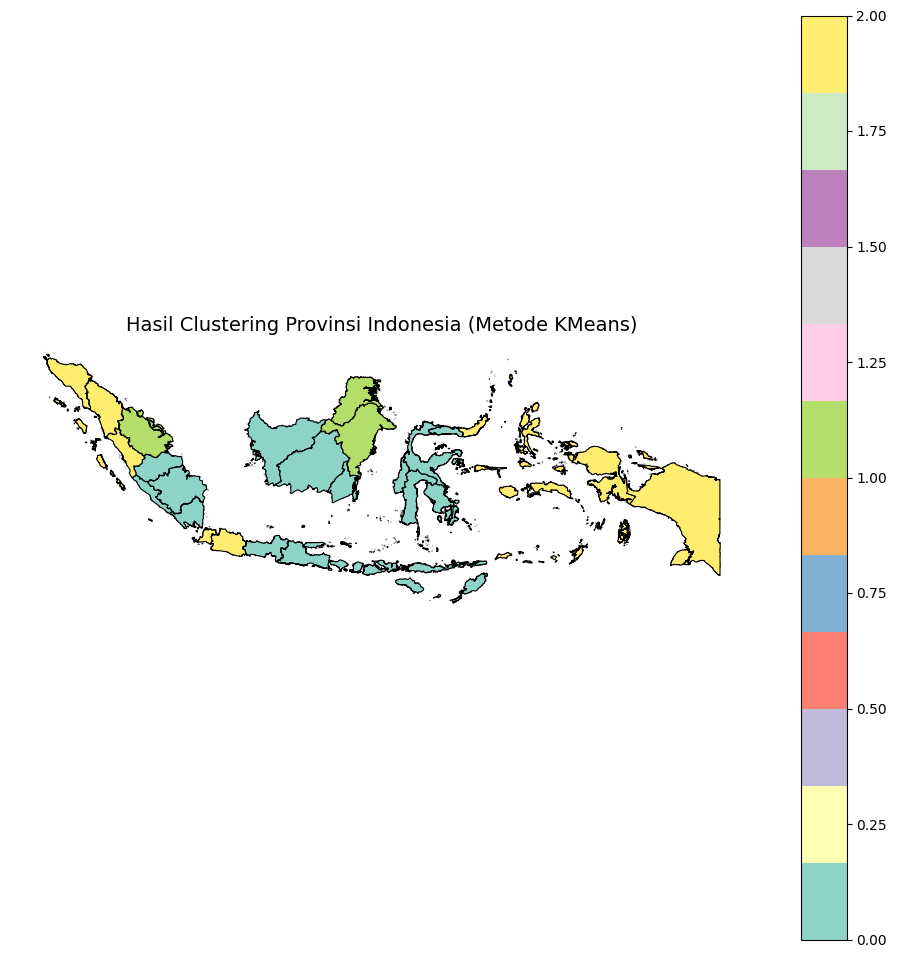

In [50]:
# 1. Baca SHP provinsi Indonesia dari GADM
gdf_prov = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")

# 2. Cek nama kolom provinsi (biasanya NAME_1 untuk level-1 administratif)
print(gdf_prov.columns)  # Pastikan nama kolom provinsi (biasanya 'NAME_1')

# 3. Sesuaikan ejaan nama provinsi antara SHP dan data
# Buat salinan data label
df_map = df_scaled[['Provinsi', 'KMeans']].copy()

# Contoh penyesuaian nama (jika perlu)
df_map['Provinsi'] = df_map['Provinsi'].str.upper().str.strip()
gdf_prov['NAME_1'] = gdf_prov['NAME_1'].str.upper().str.strip()

# Merge GeoDataFrame dengan label cluster
gdf_merged = gdf_prov.merge(df_map, left_on='NAME_1', right_on='Provinsi', how='left')

# 4. Plot hasil klastering per provinsi
fig, ax = plt.subplots(figsize=(12, 12))
gdf_merged.plot(column='KMeans', cmap='Set3', linewidth=0.8, edgecolor='black', legend=True, ax=ax)
plt.title('Hasil Clustering Provinsi Indonesia (Metode KMeans)', fontsize=14)
plt.axis('off')
plt.show()

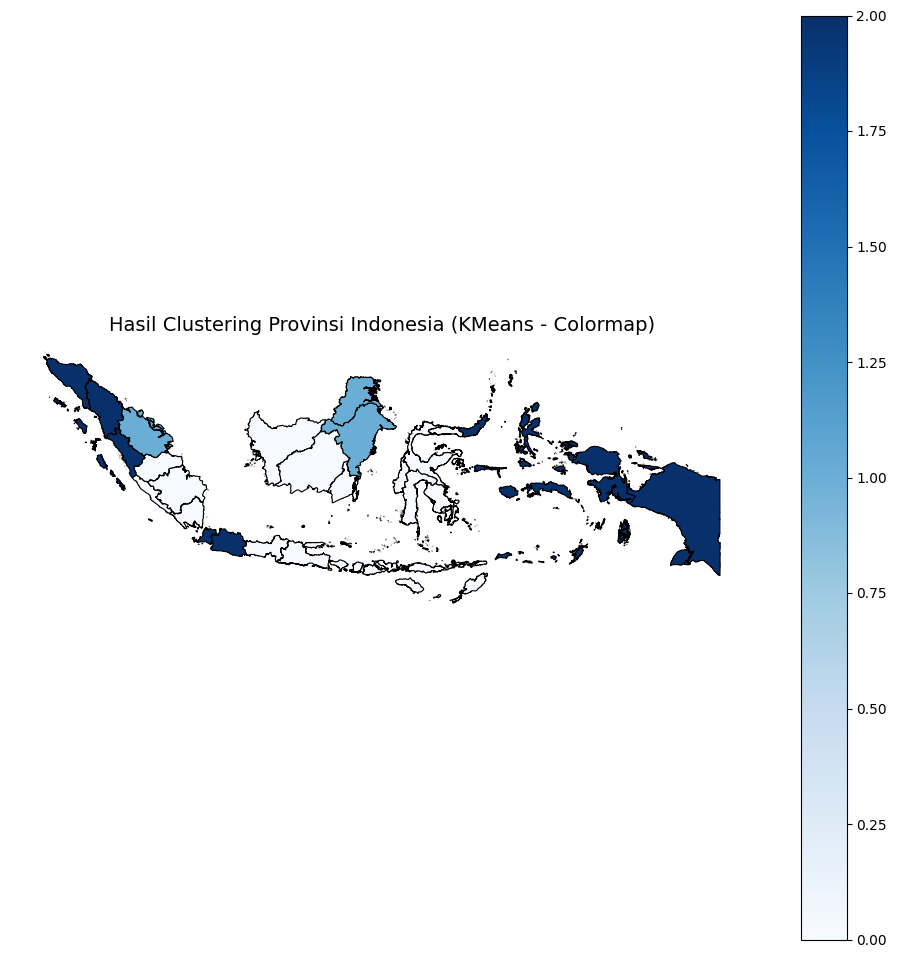

In [51]:
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Baca SHP provinsi Indonesia
gdf_prov = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")

# 2. Normalisasi nama provinsi agar match
df_map = df_scaled[['Provinsi', 'KMeans']].copy()
df_map['Provinsi'] = df_map['Provinsi'].str.upper().str.strip()
gdf_prov['NAME_1'] = gdf_prov['NAME_1'].str.upper().str.strip()

# 3. Merge
gdf_merged = gdf_prov.merge(df_map, left_on='NAME_1', right_on='Provinsi', how='left')

# 4. Pilih colormap bawaan atau warna custom
use_custom_colors = False  # ubah ke True jika ingin pakai warna sendiri

if use_custom_colors:
    # Tentukan warna per cluster (urutan: cluster 0, 1, 2, 3 dst)
    custom_colors = {
        0: '#f94144',  # merah
        1: '#f3722c',  # oranye
        2: '#90be6d',  # hijau
        3: '#577590',  # biru
    }
    gdf_merged['color'] = gdf_merged['KMeans'].map(custom_colors)

    # Plot dengan warna manual
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_merged.plot(color=gdf_merged['color'], linewidth=0.8, edgecolor='black', ax=ax)
    plt.title('Hasil Clustering Provinsi Indonesia (KMeans - Warna Kustom)', fontsize=14)
else:
    # Plot dengan colormap bawaan matplotlib
    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_merged.plot(column='KMeans', cmap='Blues', linewidth=0.8, edgecolor='black', legend=True, ax=ax)
    plt.title('Hasil Clustering Provinsi Indonesia (KMeans - Colormap)', fontsize=14)

plt.axis('off')
plt.show()


In [59]:
# 1. Baca SHP provinsi
gdf_prov = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")

# 2. Pastikan nama kolom cocok
gdf_prov['NAME_1'] = gdf_prov['NAME_1'].str.upper().str.strip()
df_map = df_scaled[['Provinsi', 'KMeans']].copy()
df_map['Provinsi'] = df_map['Provinsi'].str.upper().str.strip()

# 3. Merge
gdf_merged = gdf_prov.merge(df_map, left_on='NAME_1', right_on='Provinsi', how='left')

# 4. Isi NaN di kolom KMeans agar tidak muncul legenda berlebih
gdf_merged['KMeans'] = gdf_merged['KMeans'].fillna(-1)

# 5. Buat colormap khusus
import matplotlib.colors as mcolors

cluster_colors = {
    0: '#3B3B98',   # hijau
    1: '#96DCFD',   # oranye
    2: '#FFE066',   # biru
    -1: '#d9d9d9'   # abu-abu untuk "No Data"
}

# Plot
fig, ax = plt.subplots(figsize=(120, 120))
gdf_merged.plot(
    column='KMeans',
    cmap=mcolors.ListedColormap([cluster_colors[i] for i in sorted(cluster_colors.keys())]),
    legend=True,
    linewidth=3,
    edgecolor='#ffffff',
    ax=ax
)

# Legend manual
from matplotlib.patches import Patch
legend_labels = [
    Patch(facecolor=cluster_colors[0], label='Cluster 0'),
    Patch(facecolor=cluster_colors[1], label='Cluster 1'),
    Patch(facecolor=cluster_colors[2], label='Cluster 2'),
    Patch(facecolor=cluster_colors[-1], label='No Data')
]
plt.legend(handles=legend_labels, loc='lower left')

plt.title('Hasil Clustering Provinsi Indonesia (KMeans)', fontsize=14)
plt.axis('off')
plt.show()

In [53]:
# Gabung cluster dengan data asli (pakai data sebelum dinormalisasi kalau bisa)
df_clustered = df.copy()  # df_raw: data awal sebelum scaling
df_clustered['Cluster'] = df_scaled['KMeans']  # pastikan urutan sama


In [56]:
df_scaled.groupby('KMeans').mean(numeric_only=True)


,NEET,PDB_per_kapita,Pengangguran,RLS_Laki,RLS_Wanita,Cluster_KMeans,DBSCAN,GMM,Hierarchical
KMeans,,,,,,,,,
0,-0.386758,-0.362616,-0.508235,-0.303580,-0.188929,0.0,0.800000,0.0,0.000000
1,-0.725611,2.150802,0.493205,1.064720,1.035681,1.0,-0.200000,1.0,0.800000
2,0.911258,-0.271220,1.005375,0.584135,0.437467,2.0,-0.181818,2.0,2.454545
3,0.669690,-0.259139,-1.680225,-2.838738,-3.105974,0.0,-1.000000,3.0,2.000000
